# Classification algorithms

### Dataset description, visualisation, and pre-processing

<div class="alert alert-block alert-warning">The Heart Disease Detection dataset is composed of a set of characteristics used to determine if a patient has heart disease or not. Its main purpose is to perform classification based on the target variable, 'HeartDisease,' which indicates the presence of heart disease in the patient. This variable has integer values where 0 represents no disease and 1 indicates the presence of disease.
<div/>

<div class="alert alert-block alert-danger"> 
    
1. Import the Heart Disease Detection dataset.
2. Display and try to understand each feature in this dataset.
3. Display a summary of the dataset.
4. Verify if the dataset contains any missing values.
5. Plot the distribution of samples according to the target variable HeartDisease. Determine if the dataset is balanced.
6. Apply dummy encoding to all categorical features in the dataset.
7. Display the Pearson correlation matrix. Is there a correlation with the class and between features by considering a thresholed of 0.5?
8. Display the distribution of all features on all the scaled data (except binary features) using a histplot. What do you observe?
9. Split the data into a training and a testing set using a ratio of 0.3.
10. Normalize the data using z-score scaling.

<div/>

In [3]:
import pandas as pd 
df = pd.read_csv(r"heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Display information about data types and non-null values
df.info()

# Display basic statistics for numeric features
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:

# Display unique values for categorical features
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()}")


Sex unique values: ['M' 'F']
ChestPainType unique values: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG unique values: ['Normal' 'ST' 'LVH']
ExerciseAngina unique values: ['N' 'Y']
ST_Slope unique values: ['Up' 'Flat' 'Down']


In [6]:
# Summary combining numeric and categorical features
summary = pd.DataFrame({
    'Feature': df.columns,
    'Type': [df[col].dtype for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isnull().sum() for col in df.columns],
    'Example Values': [df[col].unique()[:5] for col in df.columns]
})

summary


,Feature,Type,Unique Values,Missing Values,Example Values
0,Age,int64,50,0,"[40, 49, 37, 48, 54]"
1,Sex,object,2,0,"[M, F]"
2,ChestPainType,object,4,0,"[ATA, NAP, ASY, TA]"
3,RestingBP,int64,67,0,"[140, 160, 130, 138, 150]"
4,Cholesterol,int64,222,0,"[289, 180, 283, 214, 195]"
5,FastingBS,int64,2,0,"[0, 1]"
6,RestingECG,object,3,0,"[Normal, ST, LVH]"
7,MaxHR,int64,119,0,"[172, 156, 98, 108, 122]"
8,ExerciseAngina,object,2,0,"[N, Y]"
9,Oldpeak,float64,53,0,"[0.0, 1.0, 1.5, 2.0, 3.0]"


In [7]:
missing_values = df.isnull().values.any()
print(missing_values)

False


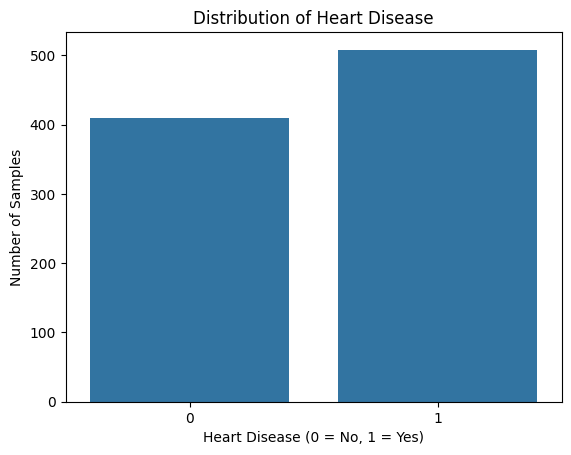

Counts:
 HeartDisease
1    508
0    410
Name: count, dtype: int64

Percentage:
 HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot of target variable
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Samples")
plt.show()

# Check percentage distribution
target_counts = df['HeartDisease'].value_counts()
target_percent = df['HeartDisease'].value_counts(normalize=True) * 100
print("Counts:\n", target_counts)
print("\nPercentage:\n", target_percent)


 it is balanced 

In [9]:
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()


Sex unique values: ['M' 'F']
ChestPainType unique values: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG unique values: ['Normal' 'ST' 'LVH']
ExerciseAngina unique values: ['N' 'Y']
ST_Slope unique values: ['Up' 'Flat' 'Down']


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


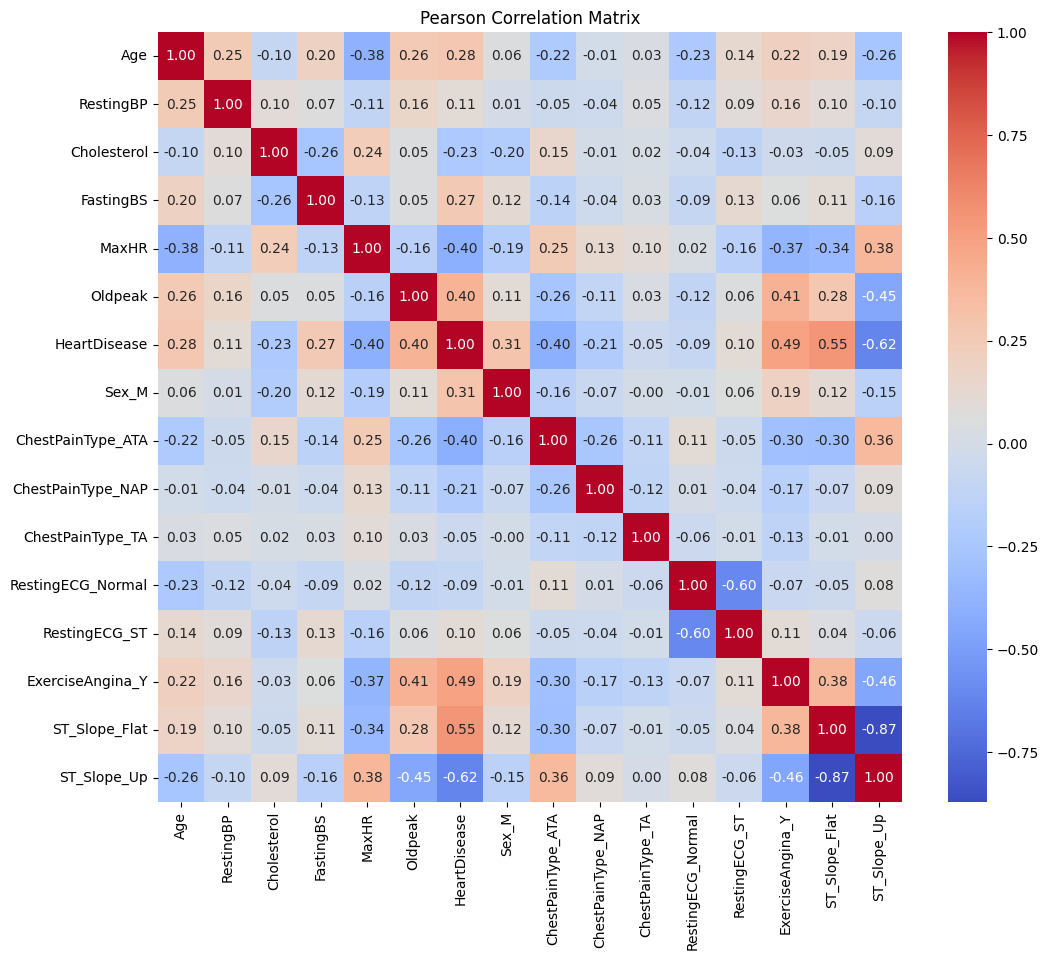

In [10]:
corr_matrix = df_encoded.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix")
plt.show()

In [11]:
# Correlation of all features with target
corr_target = corr_matrix['HeartDisease'].sort_values(ascending=False)
print("Correlation with HeartDisease:\n", corr_target)


Correlation with HeartDisease:
 HeartDisease         1.000000
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64


In [12]:
# Strong correlation with target
strong_corr_target = corr_target[abs(corr_target) >= 0.5]
print("\nFeatures strongly correlated with HeartDisease (|corr| >= 0.5):")
print(strong_corr_target)



Features strongly correlated with HeartDisease (|corr| >= 0.5):
HeartDisease     1.000000
ST_Slope_Flat    0.554134
ST_Slope_Up     -0.622164
Name: HeartDisease, dtype: float64


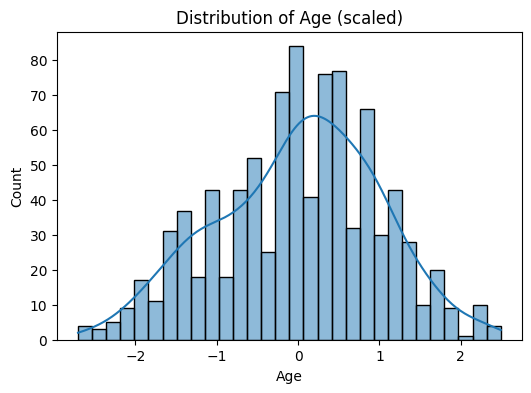

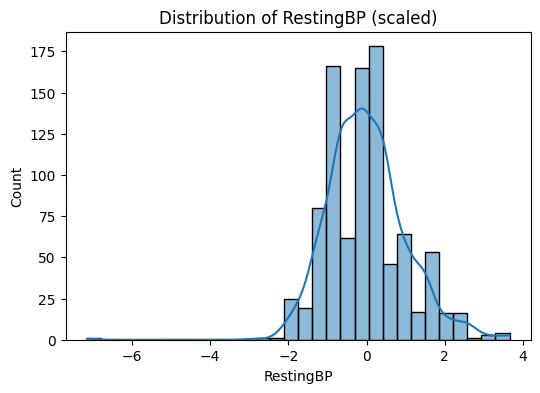

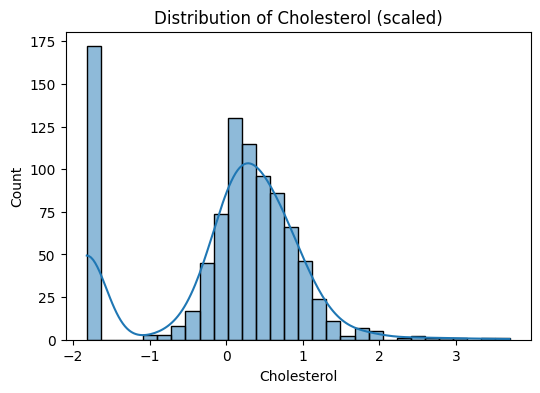

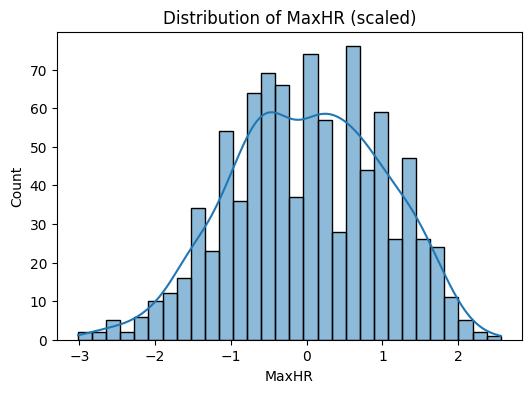

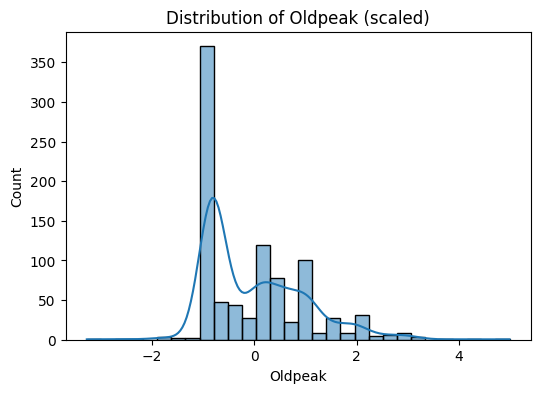

In [13]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric features (excluding binary 0/1 features)
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Copy dataframe
df_scaled = df_encoded.copy()

# Scale numeric features using z-score
scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Plot histograms for all scaled numeric features
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_scaled[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} (scaled)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_scaled.drop('HeartDisease', axis=1)
y = df_scaled['HeartDisease']

# Split (70% train, 30% test), stratify to keep class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (642, 15)
Testing set: (276, 15)


In [15]:
# Re-scale numeric features using training data
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


### Data training and performance evaluation

<div class="alert alert-block alert-danger"> 
    
1. Train the following algorithms on the generated training dataset: Gaussian Naive Bayes, KNN(K=3), and decision tree (max_depth=6).
2.  svn logistic regression 
3. Display and save the tree generated by the decision tree algorithm.
4. Implement the SVM algorithm from scratch and apply it to the dataset.
5. Print the classification reports and confusion matrices of all models on the testing set. Discuss the obtained results.
6. Display the ROC curves of the generated models in one plot.
7. Which evaluation metric do you recommend for this dataset?
8. Predict the class of the third sample from the testing set based on the best-performing model.
9. Perform the cross-validation evaluation method on the best model based on the selected metric.
</div>

In [44]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("Gaussian Naive Bayes:\n", classification_report(y_test, y_pred_gnb))


Gaussian Naive Bayes:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       123
           1       0.92      0.90      0.91       153

    accuracy                           0.90       276
   macro avg       0.90      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276



In [93]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN (k=3):\n", classification_report(y_test, y_pred_knn))


KNN (k=3):
               precision    recall  f1-score   support

           0       0.87      0.79      0.83       123
           1       0.84      0.91      0.87       153

    accuracy                           0.86       276
   macro avg       0.86      0.85      0.85       276
weighted avg       0.86      0.86      0.85       276



In [94]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree (max_depth=4):\n", classification_report(y_test, y_pred_dt))


Decision Tree (max_depth=4):
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       123
           1       0.85      0.90      0.87       153

    accuracy                           0.86       276
   macro avg       0.86      0.85      0.85       276
weighted avg       0.86      0.86      0.85       276



In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Create Decision Tree with entropy criterion
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

# Train the model
dt_entropy.fit(X_train, y_train)

# Predict on test set
y_pred_dt_entropy = dt_entropy.predict(X_test)

# Evaluate
print("Decision Tree (max_depth=4, criterion='entropy'):\n")
print(classification_report(y_test, y_pred_dt_entropy))


Decision Tree (max_depth=4, criterion='entropy'):

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       123
           1       0.85      0.84      0.85       153

    accuracy                           0.83       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.83      0.83      0.83       276



In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create Random Forest with entropy criterion
rf_entropy = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    criterion='entropy',     # Use information gain
    max_depth=4,             # Limit depth of each tree
    random_state=42
)

# Train the model
rf_entropy.fit(X_train, y_train)

# Predict on test set
y_pred_rf_entropy = rf_entropy.predict(X_test)

# Evaluate
print("Random Forest (max_depth=4, criterion='entropy'):\n")
print(classification_report(y_test, y_pred_rf_entropy))


Random Forest (max_depth=4, criterion='entropy'):

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       123
           1       0.86      0.91      0.89       153

    accuracy                           0.87       276
   macro avg       0.87      0.86      0.87       276
weighted avg       0.87      0.87      0.87       276



In [97]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


In [98]:
# Initialize SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM (Linear Kernel) Performance:")
print(classification_report(y_test, y_pred_svm))


SVM (Linear Kernel) Performance:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       123
           1       0.87      0.91      0.89       153

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276



In [99]:
# Initialize SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM (Linear Kernel) Performance:")
print(classification_report(y_test, y_pred_svm))


SVM (Linear Kernel) Performance:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       123
           1       0.90      0.94      0.92       153

    accuracy                           0.91       276
   macro avg       0.91      0.91      0.91       276
weighted avg       0.91      0.91      0.91       276



In [100]:
# Initialize Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)

# Predict
y_pred_logreg = logreg_model.predict(X_test)

# Evaluation
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logreg))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       123
           1       0.88      0.92      0.90       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276



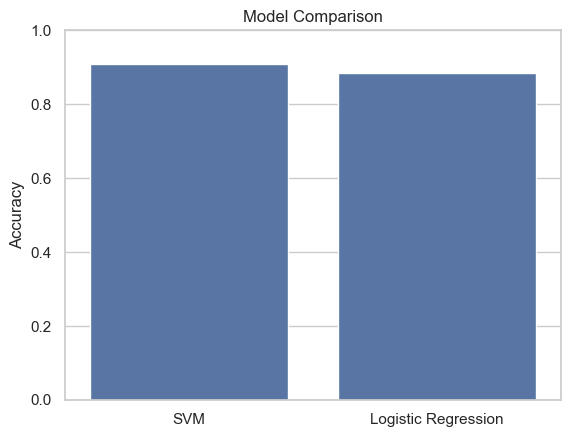

In [101]:
models = ['SVM', 'Logistic Regression']
accuracy = [
    svm_model.score(X_test, y_test),
    logreg_model.score(X_test, y_test)
]

sns.barplot(x=models, y=accuracy)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()


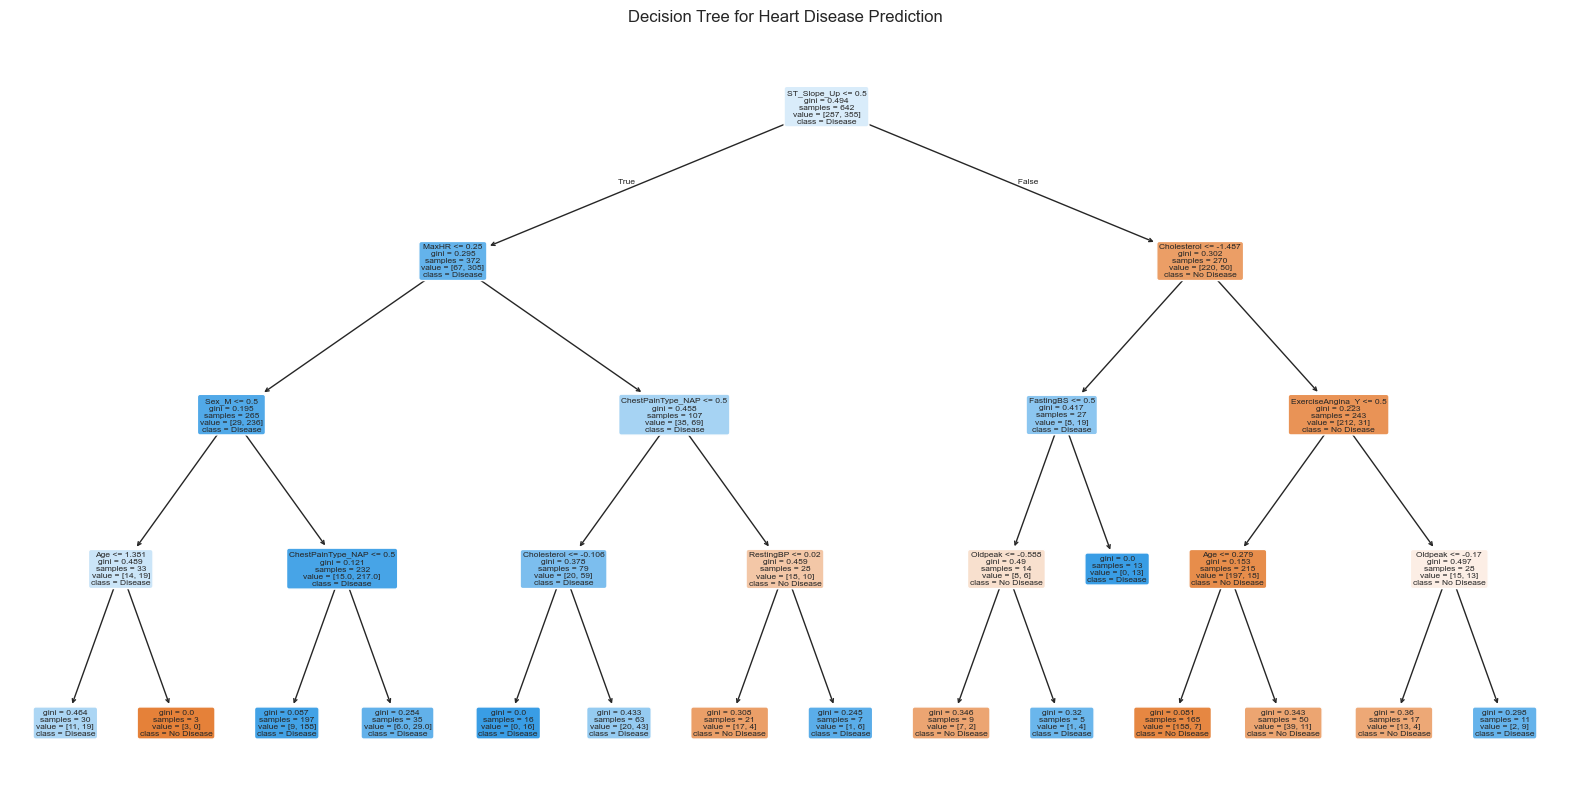

<Figure size 640x480 with 0 Axes>

In [102]:
from sklearn.tree import plot_tree, export_graphviz
import matplotlib.pyplot as plt

# Assume dt is your trained Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train.columns, class_names=['No Disease', 'Disease'], filled=True, rounded=True)
plt.title('Decision Tree for Heart Disease Prediction')
plt.show()

# Save the tree as PNG
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')

# Optionally, export to DOT file for more advanced visualization
export_graphviz(dt, out_file='decision_tree.dot', 
                feature_names=X_train.columns, 
                class_names=['No Disease', 'Disease'],
                filled=True, rounded=True)


In [103]:

class LinearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Convert y labels to -1, 1
        y_ = np.where(y == 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.where(approx >= 0, 1, 0)


In [104]:
svm_scratch = LinearSVM(lr=0.01, lambda_param=0.001, n_iters=5000)
svm_scratch.fit(X_train_scaled, y_train_numeric.values)
print("Class distribution in y_train:")
print(np.bincount(y_train_numeric))
from sklearn.metrics import classification_report
print(classification_report(y_test_numeric, y_pred_scratch, zero_division=1))



Class distribution in y_train:
[287 355]
              precision    recall  f1-score   support

           0       0.45      1.00      0.62       123
           1       1.00      0.00      0.00       153

    accuracy                           0.45       276
   macro avg       0.72      0.50      0.31       276
weighted avg       0.75      0.45      0.27       276



In [111]:
# Gaussian Naive Bayes
y_prob_gnb = gnb.predict_proba(X_test)[:,1]

# KNN
y_prob_knn = knn.predict_proba(X_test)[:,1]

# Decision Tree
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Logistic Regression
y_prob_logreg = logreg_model.predict_proba(X_test)[:,1]

# SVM from scikit-learn (linear kernel)
svm_model_prob = SVC(kernel='linear', probability=True, random_state=42)
svm_model_prob.fit(X_train, y_train)
y_prob_svm = svm_model_prob.predict_proba(X_test)[:,1]
# تحويل الاحتمالات إلى تصنيف نهائي باستخدام عتبة 0.5
y_pred_svm_final = (y_prob_svm >= 0.5).astype(int)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm_final, zero_division=1))



              precision    recall  f1-score   support

           0       0.88      0.85      0.86       123
           1       0.88      0.91      0.89       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276



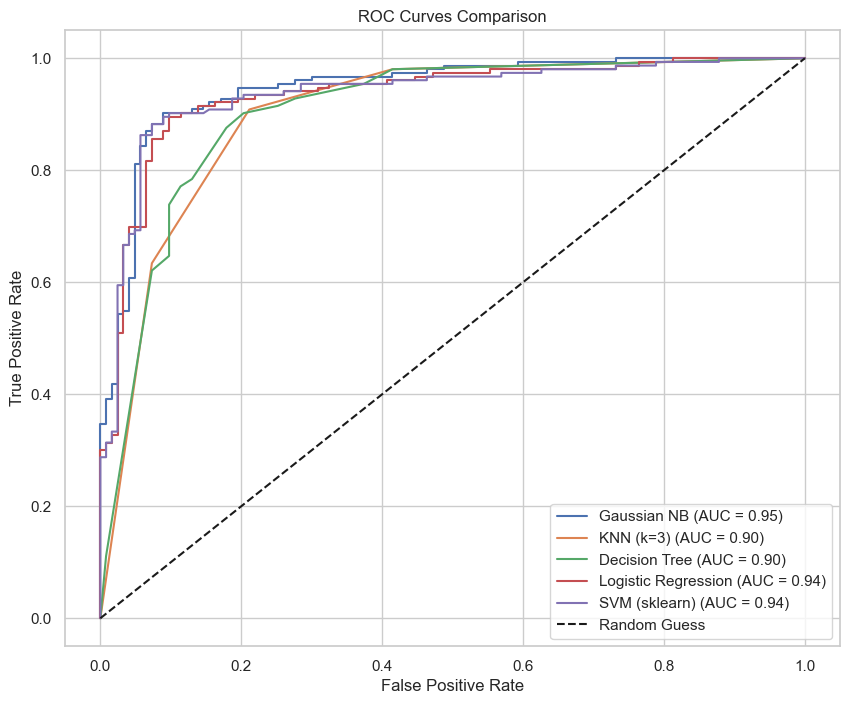

In [106]:
plt.figure(figsize=(10,8))

# Helper function to plot ROC
def plot_roc(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

# Plot all models
plot_roc(y_test, y_prob_gnb, "Gaussian NB")
plot_roc(y_test, y_prob_knn, "KNN (k=3)")
plot_roc(y_test, y_prob_dt, "Decision Tree")
plot_roc(y_test, y_prob_logreg, "Logistic Regression")
plot_roc(y_test, y_prob_svm, "SVM (sklearn)")

# Plot diagonal line for random guess
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


In [107]:
# Dictionary of F1 scores
f1_scores = {
    'Gaussian NB': f1_gnb,
    'KNN': f1_knn,
    'Decision Tree': f1_dt,
    'Logistic Regression': f1_logreg,
    'SVM': f1_svm
}

# Select model with highest F1
best_model_name = max(f1_scores, key=f1_scores.get)
print("Best model based on F1 score:", best_model_name)

# Map model names to actual trained objects
models_dict = {
    'Gaussian NB': gnb,
    'KNN': knn,
    'Decision Tree': dt,
    'Logistic Regression': logreg_model,
    'SVM': svm_model
}

best_model = models_dict[best_model_name]


Best model based on F1 score: Gaussian NB


In [108]:
third_sample = X_test.iloc[2:3]  # third sample

predicted_class = best_model.predict(third_sample)
print(f"Predicted class of the third test sample: {predicted_class[0]}")

# Probability (if available)
if hasattr(best_model, "predict_proba"):
    prob = best_model.predict_proba(third_sample)[0,1]
    print(f"Probability of having heart disease: {prob:.2f}")


Predicted class of the third test sample: 1
Probability of having heart disease: 1.00


In [109]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate F1 score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1')
print(f"Cross-Validation F1 scores: {cv_scores}")
print(f"Mean F1 score: {cv_scores.mean():.3f}")


Cross-Validation F1 scores: [0.82432432 0.89189189 0.86713287 0.85714286 0.88405797]
Mean F1 score: 0.865
